
# Lab 3: Data Cleaning & Feature Engineering
**Student Name:** Shaheer Khan  
**Registration No:** 22JZELE0457  

This notebook covers three critical steps in the data preprocessing pipeline for time‑series forecasting:
1. **Handling Missing Data** – identifying and interpolating missing timestamps.
2. **Outlier Detection** – using the IQR method to detect and treat outliers.
3. **Holiday Feature Engineering** – merging holiday information and creating a binary holiday indicator.

All steps are performed on the American Electric Power (AEP) hourly energy consumption dataset.



## Part 1: Missing Data Handling

### Objective
- Load the raw AEP hourly dataset.
- Inspect the time range and identify missing timestamps.
- Resample to an hourly frequency and interpolate missing values.
- Save the cleaned dataset.

### Steps
1. Load data and convert `Datetime` to datetime type.
2. Set `Datetime` as index.
3. Generate full hourly date range and find missing timestamps.
4. Resample to fill missing timestamps with `NaN`.
5. Interpolate missing values using linear interpolation.
6. Verify that no missing values remain.
7. Save the result.


In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# -----------------------------
# 1. Load data
# -----------------------------
# Adjust the path to your data file
df = pd.read_csv(r'C:\Users\PMYLS\Documents\MachineLearningLaB\AEP_hourly.csv', parse_dates=['Datetime'])
print("Original data shape:", df.shape)
df.head()


Original data shape: (121273, 2)


,Datetime,AEP_MW
0,2004-12-31 01:00:00,13478.0
1,2004-12-31 02:00:00,12865.0
2,2004-12-31 03:00:00,12577.0
3,2004-12-31 04:00:00,12517.0
4,2004-12-31 05:00:00,12670.0


In [3]:

# -----------------------------
# 2. Convert to datetime and set index
# -----------------------------
df['Datetime'] = pd.to_datetime(df['Datetime'])
df.set_index('Datetime', inplace=True)
df.head()


,AEP_MW
Datetime,
2004-12-31 01:00:00,13478.0
2004-12-31 02:00:00,12865.0
2004-12-31 03:00:00,12577.0
2004-12-31 04:00:00,12517.0
2004-12-31 05:00:00,12670.0


In [4]:

# -----------------------------
# 3. Check for missing timestamps
# -----------------------------
# Generate full hourly range from start to end
full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='H')
missing_ts = full_range.difference(df.index)
print(f"Number of missing timestamps: {len(missing_ts)}")
print("First few missing timestamps:", missing_ts[:5].tolist())


Number of missing timestamps: 27
First few missing timestamps: [Timestamp('2004-10-31 02:00:00'), Timestamp('2005-04-03 03:00:00'), Timestamp('2005-10-30 02:00:00'), Timestamp('2006-04-02 03:00:00'), Timestamp('2006-10-29 02:00:00')]


In [5]:

# -----------------------------
# 4. Resample to ensure all hours are present
# -----------------------------
# Resample at hourly frequency, taking the first value if multiple exist,
# and filling missing with NaN.
df_resampled = df.resample('H').first()
print("After resampling shape:", df_resampled.shape)
# Check missing values
print("Missing values before interpolation:\n", df_resampled.isnull().sum())


After resampling shape: (121296, 1)
Missing values before interpolation:
 AEP_MW    27
dtype: int64


In [6]:

# -----------------------------
# 5. Interpolate missing values
# -----------------------------
# Using linear interpolation (can also use 'time' method)
df_resampled['AEP_MW'] = df_resampled['AEP_MW'].interpolate(method='linear')
# Verify no missing
print("Missing values after interpolation:\n", df_resampled.isnull().sum())


Missing values after interpolation:
 AEP_MW    0
dtype: int64


In [ ]:

# -----------------------------
# 6. Save the cleaned data
# -----------------------------
# Reset index to have Datetime as a column again
df_clean = df_resampled.reset_index()
df_clean.to_csv('2_Missing_Values_Filled.csv', index=False)
print("Saved to '2_Missing_Values_Filled.csv'")
print("Final shape:", df_clean.shape)



## Part 2: Outlier Identification using IQR

### Objective
- Load the dataset with filled missing values.
- Visualize the distribution using a boxplot.
- Apply the Interquartile Range (IQR) method to detect outliers.
- Replace outliers with `NaN` and then interpolate them.
- Save the outlier‑treated dataset.

### IQR Method
- Calculate Q1 (25th percentile) and Q3 (75th percentile).
- Compute IQR = Q3 − Q1.
- Define lower bound = Q1 − 1.5×IQR, upper bound = Q3 + 1.5×IQR.
- Values outside these bounds are considered outliers.


In [7]:

# -----------------------------
# 1. Load data with missing values filled
# -----------------------------
df = pd.read_csv(r'C:\Users\PMYLS\Documents\MachineLearningLaB\2_Missing_Values_Filled.csv', parse_dates=['Datetime'], index_col='Datetime')
print("Data shape:", df.shape)
df.head()


Data shape: (121296, 1)


,AEP_MW
Datetime,
2004-10-01 01:00:00,12379.0
2004-10-01 02:00:00,11935.0
2004-10-01 03:00:00,11692.0
2004-10-01 04:00:00,11597.0
2004-10-01 05:00:00,11681.0


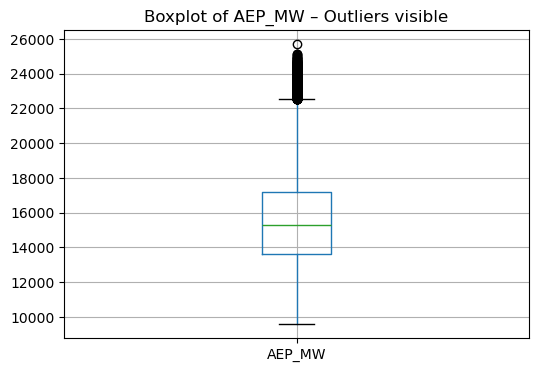

In [8]:

# -----------------------------
# 2. Boxplot to visualize outliers
# -----------------------------
plt.figure(figsize=(6,4))
df.boxplot('AEP_MW')
plt.title('Boxplot of AEP_MW – Outliers visible')
plt.show()


In [9]:

# -----------------------------
# 3. IQR outlier detection function
# -----------------------------
def detect_outliers_iqr(data):
    q1 = data['AEP_MW'].quantile(0.25)
    q3 = data['AEP_MW'].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    print(f"Q1: {q1:.2f}, Q3: {q3:.2f}, IQR: {iqr:.2f}")
    print(f"Lower bound: {lower_bound:.2f}, Upper bound: {upper_bound:.2f}")

    # Mark outliers as NaN
    data.loc[data['AEP_MW'] < lower_bound, 'AEP_MW'] = np.nan
    data.loc[data['AEP_MW'] > upper_bound, 'AEP_MW'] = np.nan

    # Return indices of outliers
    outlier_indices = data[data['AEP_MW'].isnull()].index.tolist()
    return outlier_indices

outlier_idx = detect_outliers_iqr(df)
print(f"Number of outliers detected: {len(outlier_idx)}")
print("First few outlier indices:", outlier_idx[:10])


Q1: 13629.00, Q3: 17200.00, IQR: 3571.00
Lower bound: 8272.50, Upper bound: 22556.50
Number of outliers detected: 666
First few outlier indices: [Timestamp('2004-12-20 09:00:00'), Timestamp('2005-01-18 08:00:00'), Timestamp('2005-01-18 09:00:00'), Timestamp('2005-01-24 08:00:00'), Timestamp('2005-01-24 09:00:00'), Timestamp('2005-06-27 16:00:00'), Timestamp('2005-06-27 17:00:00'), Timestamp('2005-07-21 15:00:00'), Timestamp('2005-07-21 16:00:00'), Timestamp('2005-07-21 17:00:00')]


In [10]:

# -----------------------------
# 4. Interpolate the outlier positions
# -----------------------------
# Use time-based interpolation for time series
df['AEP_MW'] = df['AEP_MW'].interpolate(method='time')
# Verify no missing values remain
print("Missing after interpolation:", df['AEP_MW'].isnull().sum())


Missing after interpolation: 0


In [ ]:

# -----------------------------
# 5. Save the outlier‑treated data
# -----------------------------
df.reset_index(inplace=True)
df.to_csv('3_Outlier_Identified.csv', index=False)
print("Saved to '3_Outlier_Identified.csv'")



## Part 3: Holiday Feature Engineering

### Objective
- Load the outlier‑treated data.
- Load a separate holiday dataset containing US holidays.
- Merge holiday information into the main dataset.
- Create a binary indicator `Holiday` (1 if holiday, else 0).
- Save the final dataset with the new feature.

### Steps
1. Load the outlier‑treated data and extract date part.
2. Load holiday dataset.
3. Merge on date (left join).
4. Convert holiday names to binary indicator using `notnull()`.
5. Save the final dataset.


In [11]:

# -----------------------------
# 1. Load outlier‑treated data
# -----------------------------
df = pd.read_csv(r'C:\Users\PMYLS\Documents\MachineLearningLaB\3_Outlier_Identified.csv', parse_dates=['Datetime'])
# Extract date (without time) for merging
df['Date'] = df['Datetime'].dt.normalize()
print("Data shape:", df.shape)
df.head()


Data shape: (121296, 3)


,Datetime,AEP_MW,Date
0,2004-10-01 01:00:00,12379.0,2004-10-01
1,2004-10-01 02:00:00,11935.0,2004-10-01
2,2004-10-01 03:00:00,11692.0,2004-10-01
3,2004-10-01 04:00:00,11597.0,2004-10-01
4,2004-10-01 05:00:00,11681.0,2004-10-01


In [12]:

# -----------------------------
# 2. Load holiday dataset
# -----------------------------
# This file should contain columns: Date, Holiday, WeekDay, Month, Day, Year
holiday_df = pd.read_csv(r'C:\Users\PMYLS\Documents\MachineLearningLaB\processed_holiday.csv', parse_dates=['Date'])
print("Holiday data shape:", holiday_df.shape)
holiday_df.head()


Holiday data shape: (279, 6)


,Date,Holiday,WeekDay,Month,Day,Year
0,2004-01-01,New Year's Day,Thursday,1,1,2004
1,2004-01-19,"Martin Luther King, Jr. Day",Monday,1,19,2004
2,2004-02-14,Valentine’s Day,Saturday,2,14,2004
3,2004-02-16,Washington's Birthday,Monday,2,16,2004
4,2004-04-11,Eastern Easter,Sunday,4,11,2004


In [13]:

# -----------------------------
# 3. Keep only necessary columns from holiday data
# -----------------------------
holiday_df = holiday_df[['Date', 'Holiday']]
holiday_df.head()


,Date,Holiday
0,2004-01-01,New Year's Day
1,2004-01-19,"Martin Luther King, Jr. Day"
2,2004-02-14,Valentine’s Day
3,2004-02-16,Washington's Birthday
4,2004-04-11,Eastern Easter


In [14]:

# -----------------------------
# 4. Merge with main data (left join)
# -----------------------------
merged = pd.merge(df, holiday_df, on='Date', how='left')
print("Merged shape:", merged.shape)
# Check missing holiday entries – those are non‑holidays
merged['Holiday'].isnull().sum()


Merged shape: (121296, 4)


115104

In [15]:

# -----------------------------
# 5. Convert to binary indicator
# -----------------------------
merged['Holiday'] = merged['Holiday'].notnull().astype(int)
# Verify: count of holidays
print("Number of holiday hours:", merged['Holiday'].sum())
merged.head()


Number of holiday hours: 6192


,Datetime,AEP_MW,Date,Holiday
0,2004-10-01 01:00:00,12379.0,2004-10-01,0
1,2004-10-01 02:00:00,11935.0,2004-10-01,0
2,2004-10-01 03:00:00,11692.0,2004-10-01,0
3,2004-10-01 04:00:00,11597.0,2004-10-01,0
4,2004-10-01 05:00:00,11681.0,2004-10-01,0


In [ ]:

# -----------------------------
# 6. Save final dataset
# -----------------------------
merged.to_csv('4_AEP_Introducing_holidays.csv', index=False)
print("Saved to '4_AEP_Introducing_holidays.csv'")
print("Final columns:", merged.columns.tolist())



## Summary

This combined lab demonstrated a complete data cleaning and feature engineering pipeline:
- **Missing data** was identified by resampling and filled via interpolation.
- **Outliers** were detected using the IQR method and then interpolated.
- **Holiday feature** was created by merging with a holiday calendar and binarizing.

All steps are essential for preparing high‑quality time‑series data for machine learning models.

---

**Prepared by:** Shaheer Khan (22JZELE0457)  
